In [9]:
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
from pathlib import Path
import seaborn as sns
from sklearn.metrics import confusion_matrix
import pynapple as nap
from spatial_manifolds.toroidal import *
from spatial_manifolds.behaviour_plots import *
from matplotlib.colors import TwoSlopeNorm
from scipy.spatial import distance
from spatial_manifolds.circular_decoder import circular_decoder, cross_validate_decoder, cross_validate_decoder_time, circular_nanmean
import random

from spatial_manifolds.data.curation import curate_clusters
from scipy.stats import zscore
from spatial_manifolds.util import gaussian_filter_nan
from spatial_manifolds.predictive_grid import compute_travel_projected, wrap_list
from spatial_manifolds.behaviour_plots import *
from spatial_manifolds.behaviour_plots import trial_cat_priority
from spatial_manifolds.detect_grids import *
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import matplotlib.cm as cm
import numpy as np

import warnings
warnings.filterwarnings('ignore')

fig_path = '/Users/harryclark/Documents/figs/FIGURE1/'


In [5]:
# order recordings by shank medial to lateral
mouse_days = {20: [25,23,24,26],
              21: [26,23,23,24],
              25: [24,19,22,23],
              26: [17,18,11,12],
              27: [22,26,23,24],
              28: [22,21,19,20],
              29: [22,21,19,20],
            }

df = pd.DataFrame()
for mouse, days in mouse_days.items():
    for day, shank in zip(days, [0,1,2,3]):
        gcs, ngs, ns, sc, ngs_ns, all = cell_classification_of1(mouse, day, percentile_threshold=95) # subset
        spatial_cells = pd.concat([gcs, ngs], ignore_index=True)

        rc, rsc, vr_ns = cell_classification_vr(mouse, day)
        tcs, tcs_time, autocorrs, last_ephys_bin, beh, clusters = compute_vr_tcs(mouse, day)

        # get session info
        trial_groups, trial_colors = get_trial_groups_and_colors(beh, last_ephys_bin, tl, bs)
        sorted_trial_indices, sorted_trial_colors = get_sorted_trials_and_colors(beh, last_ephys_bin, tl, bs)
        tns = beh['trial_number']
        dt = beh['travel']-((tns[0]-1)*tl)
        n_bins = int(int(((np.ceil(np.nanmax(dt))//tl)+1)*tl)/bs)
        max_bound = int(((np.ceil(np.nanmax(dt))//tl)+1)*tl)
        min_bound = 0
        dt_bins = np.arange(0,max_bound,bs)
        x_true_dt = dt_bins[:last_ephys_bin]
        true_position = x_true_dt%tl
        trial_numbers = (x_true_dt//tl)+beh['trials']['number'][0]
        
        for trial_type_set, trial_type_set_label in zip([np.array(['b','nb']), np.array(['b']), np.array(['nb'])], ['b_nb', 'b', 'nb']):
            for cluster_ids, cell_type_label in zip([gcs.cluster_id.values, ngs.cluster_id.values, spatial_cells.cluster_id.values], ['GC', 'NGS', 'S']):

                tns_to_decode = np.array(beh['trials']['number'][(np.isin(beh['trials']['type'], trial_type_set)) &
                                                                        (np.isin(beh['trials']['performance'], ['hit']))])
                tns_to_train = np.array(beh['trials']['number'][(np.isin(beh['trials']['type'], trial_type_set)) &
                                                                        (np.isin(beh['trials']['performance'], ['hit']))]) 

                tns_to_decode = tns_to_decode[tns_to_decode>0] # handles first ephys trials   
                tns_to_decode = tns_to_decode[tns_to_decode<=np.nanmax(trial_numbers)] # handles last ephys trials
                tns_to_train = tns_to_train[tns_to_train<=np.nanmax(trial_numbers)] # handles last ephys trials

                print(f'mouse: {mouse}, day: {day}, cell type: {cell_type_label}, trial type set: {trial_type_set_label}') 
                print(f'n clusters: {len(cluster_ids)}')
                print(f'n trials to decode: {len(tns_to_decode)}')
                print(f'n trials to train {len(tns_to_train)}')

                if len(cluster_ids)>0:
                    tcs_ = {cluster_id: tcs[cluster_id] for cluster_id in cluster_ids if cluster_id in tcs}
                    predictions, errors = cross_validate_decoder(tcs_, true_position, trial_numbers, tns_to_decode, 
                                                                tns_to_train, tl, bs, train=0.9, n=10, verbose=False)
                    avg_predictions = circular_nanmean(predictions, tl, axis=2)
                    avg_errors = np.nanmean(errors, axis=2)
                    
                    tmp = pd.DataFrame()
                    tmp['cell_type'] = [cell_type_label]
                    tmp['trial_type'] = [trial_type_set_label]
                    tmp['error'] = [np.nanmean(avg_errors)]
                    tmp['error_over_location'] = [avg_errors.mean(axis=0)]
                    tmp['mouse'] = [mouse]
                    tmp['day'] = [day]
                    tmp['shank'] = [shank]
                    tmp['n_cells'] = [len(cluster_ids)]
                    tmp['n_trials'] = [len(tns_to_decode)]
                    df = pd.concat([df, tmp], ignore_index=True)



there are this many clusters before curation 239
last_ephys_bin 39500
last_ephys_time_bin 1821.885033333
20 25
there are 24 non_grid and non_spatial_cells
there are 11 grid_cells
there are 18 non grid spatial cells
there are 6 non spatial cells
there are 1 speed cells
there are 36 cells
there are this many clusters before curation 239
last_ephys_bin 39500
last_ephys_time_bin 1821.885033333
mouse: 20, day: 25, cell type: GC, trial type set: b_nb
n clusters: 11
n trials to decode: 166
n trials to train 166
mouse: 20, day: 25, cell type: NGS, trial type set: b_nb
n clusters: 18
n trials to decode: 166
n trials to train 166
mouse: 20, day: 25, cell type: S, trial type set: b_nb
n clusters: 29
n trials to decode: 166
n trials to train 166
mouse: 20, day: 25, cell type: GC, trial type set: b
n clusters: 11
n trials to decode: 146
n trials to train 146
mouse: 20, day: 25, cell type: NGS, trial type set: b
n clusters: 18
n trials to decode: 146
n trials to train 146
mouse: 20, day: 25, cell ty

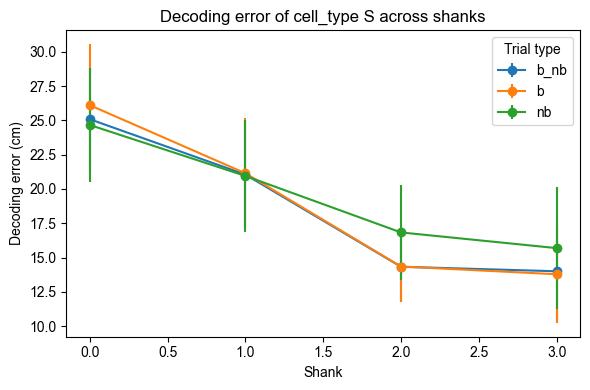

In [ ]:
import matplotlib.pyplot as plt

# Filter for cell_type 'S'
df_s = df[df['cell_type'] == 'S']

# Get unique shanks and trial_type_labels
shanks = sorted(df_s['shank'].unique())
trial_type_labels = df_s['trial_type'].unique()

fig, ax = plt.subplots(figsize=(6, 4))

for i, trial_type in enumerate(trial_type_labels):
    means = []
    sems = []
    for sh in shanks:
        vals = df_s[(df_s['shank'] == sh) & (df_s['trial_type'] == trial_type)]['error']
        means.append(vals.mean())
        sems.append(vals.sem())
    ax.errorbar(shanks, means, yerr=sems, marker='o', label=trial_type)

ax.set_xlabel('Shank')
ax.set_ylabel('Decoding error (cm)')
ax.set_title('Decoding error of cell_type S across shanks')
ax.legend(title='Trial type')
plt.tight_layout()
plt.show()


# Filter for cell_type 'S'
df_s = df[df['cell_type'] == 'S']

# Get unique shanks and trial_type_labels
shanks = sorted(df_s['shank'].unique())
trial_type_labels = df_s['trial_type'].unique()

fig, ax = plt.subplots(figsize=(6, 4))

for i, trial_type in enumerate(trial_type_labels):
    means = []
    sems = []
    for sh in shanks:
        vals = df_s[(df_s['shank'] == sh) & (df_s['trial_type'] == trial_type)]['n_cells']
        means.append(vals.mean())
        sems.append(vals.sem())
    ax.errorbar(shanks, means, yerr=sems, marker='o', label=trial_type)

ax.set_xlabel('Shank')
ax.set_ylabel('Number of cells')
ax.set_title('Number of cells per shank')
ax.legend(title='Trial type')
plt.tight_layout()
plt.show()

It looks like the change in decoding error can probably be attributed to the large difference in the number of cells in the decoder

In [20]:
# order recordings by shank medial to lateral
mouse_days = {20: [25,23,24,26],
              21: [26,23,23,24],
              25: [24,19,22,23],
              26: [17,18,11,12],
              27: [22,26,23,24],
              28: [22,21,19,20],
              29: [22,21,19,20],
            }

df = pd.DataFrame()
for mouse, days in mouse_days.items():
    cells_to_use_in_decoder = 10000
    for day, shank in zip(days, [0,1,2,3]):
        gcs, ngs, ns, sc, ngs_ns, all = cell_classification_of1(mouse, day, percentile_threshold=95) # subset
        spatial_cells = pd.concat([gcs, ngs], ignore_index=True)
        if len(spatial_cells)<cells_to_use_in_decoder:
            cells_to_use_in_decoder = len(spatial_cells)
    print(f'mouse: {mouse}, cells to use in decoder: {cells_to_use_in_decoder}')
    
    for day, shank in zip(days, [0,1,2,3]):
        gcs, ngs, ns, sc, ngs_ns, all = cell_classification_of1(mouse, day, percentile_threshold=95) # subset
        spatial_cells = pd.concat([gcs, ngs], ignore_index=True)

        rc, rsc, vr_ns = cell_classification_vr(mouse, day)
        tcs, tcs_time, autocorrs, last_ephys_bin, beh, clusters = compute_vr_tcs(mouse, day)

        # get session info
        trial_groups, trial_colors = get_trial_groups_and_colors(beh, last_ephys_bin, tl, bs)
        sorted_trial_indices, sorted_trial_colors = get_sorted_trials_and_colors(beh, last_ephys_bin, tl, bs)
        tns = beh['trial_number']
        dt = beh['travel']-((tns[0]-1)*tl)
        n_bins = int(int(((np.ceil(np.nanmax(dt))//tl)+1)*tl)/bs)
        max_bound = int(((np.ceil(np.nanmax(dt))//tl)+1)*tl)
        min_bound = 0
        dt_bins = np.arange(0,max_bound,bs)
        x_true_dt = dt_bins[:last_ephys_bin]
        true_position = x_true_dt%tl
        trial_numbers = (x_true_dt//tl)+beh['trials']['number'][0]
        
        for j in range(5): # this many permutations of the cells
            random.seed(j)  # Set seed for reproducibility
            for trial_type_set, trial_type_set_label in zip([np.array(['b','nb']), np.array(['b']), np.array(['nb'])], ['b_nb', 'b', 'nb']):
                for cluster_ids, cell_type_label in zip([spatial_cells.cluster_id.values], ['S']):

                    tns_to_decode = np.array(beh['trials']['number'][(np.isin(beh['trials']['type'], trial_type_set)) &
                                                                            (np.isin(beh['trials']['performance'], ['hit']))])
                    tns_to_train = np.array(beh['trials']['number'][(np.isin(beh['trials']['type'], trial_type_set)) &
                                                                            (np.isin(beh['trials']['performance'], ['hit']))]) 

                    tns_to_decode = tns_to_decode[tns_to_decode>0] # handles first ephys trials   
                    tns_to_decode = tns_to_decode[tns_to_decode<=np.nanmax(trial_numbers)] # handles last ephys trials
                    tns_to_train = tns_to_train[tns_to_train<=np.nanmax(trial_numbers)] # handles last ephys trials

                    print(f'mouse: {mouse}, day: {day}, cell type: {cell_type_label}, trial type set: {trial_type_set_label}') 
                    print(f'n clusters: {len(cluster_ids)}')
                    print(f'n trials to decode: {len(tns_to_decode)}')
                    print(f'n trials to train {len(tns_to_train)}')

                    if len(cluster_ids)>0:
                        tcs_ = {cluster_id: tcs[cluster_id] for cluster_id in cluster_ids if cluster_id in tcs}
                        random_keys = random.sample(list(tcs_.keys()), cells_to_use_in_decoder)
                        selected_tcs = {k: tcs_[k] for k in random_keys}
                        predictions, errors = cross_validate_decoder(selected_tcs, true_position, trial_numbers, tns_to_decode, 
                                                                    tns_to_train, tl, bs, train=0.9, n=10, verbose=False)
                        avg_predictions = circular_nanmean(predictions, tl, axis=2)
                        avg_errors = np.nanmean(errors, axis=2)
                        
                        tmp = pd.DataFrame()
                        tmp['cell_type'] = [cell_type_label]
                        tmp['trial_type'] = [trial_type_set_label]
                        tmp['error'] = [np.nanmean(avg_errors)]
                        tmp['error_over_location'] = [avg_errors.mean(axis=0)]
                        tmp['mouse'] = [mouse]
                        tmp['day'] = [day]
                        tmp['shank'] = [shank]
                        tmp['n_cells'] = [len(cluster_ids)]
                        tmp['n_cells_used'] = [cells_to_use_in_decoder]
                        tmp['n_trials'] = [len(tns_to_decode)]
                        tmp['permutation'] = [j]  # Store the selected keys for permutation
                        df = pd.concat([df, tmp], ignore_index=True)



there are this many clusters before curation 239
last_ephys_bin 39500
last_ephys_time_bin 1821.885033333
20 25
there are 24 non_grid and non_spatial_cells
there are 11 grid_cells
there are 18 non grid spatial cells
there are 6 non spatial cells
there are 1 speed cells
there are 36 cells
there are this many clusters before curation 289
last_ephys_bin 31400
last_ephys_time_bin 1808.695066667
20 23
there are 66 non_grid and non_spatial_cells
there are 3 grid_cells
there are 51 non grid spatial cells
there are 15 non spatial cells
there are 16 speed cells
there are 85 cells
there are this many clusters before curation 277
last_ephys_bin 41200
last_ephys_time_bin 1836.325
20 24
there are 77 non_grid and non_spatial_cells
there are 2 grid_cells
there are 67 non grid spatial cells
there are 10 non spatial cells
there are 1 speed cells
there are 80 cells
there are this many clusters before curation 482
last_ephys_bin 40700
last_ephys_time_bin 1816.795
20 26
there are 133 non_grid and non_spati

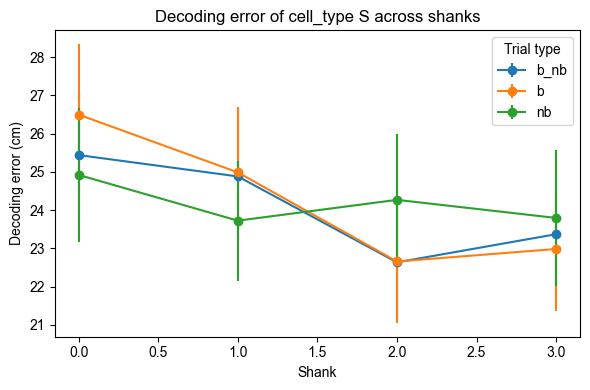

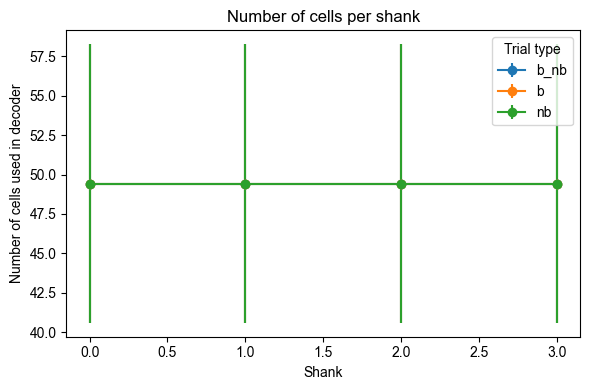

In [21]:

# Filter for cell_type 'S'
df_s = df[df['cell_type'] == 'S']

# Get unique shanks and trial_type_labels
shanks = sorted(df_s['shank'].unique())
trial_type_labels = df_s['trial_type'].unique()

fig, ax = plt.subplots(figsize=(6, 4))

for i, trial_type in enumerate(trial_type_labels):
    means = []
    sems = []
    for sh in shanks:
        vals = df_s[(df_s['shank'] == sh) & (df_s['trial_type'] == trial_type)]['error']
        means.append(vals.mean())
        sems.append(vals.sem())
    ax.errorbar(shanks, means, yerr=sems, marker='o', label=trial_type)

ax.set_xlabel('Shank')
ax.set_ylabel('Decoding error (cm)')
ax.set_title('Decoding error of cell_type S across shanks')
ax.legend(title='Trial type')
plt.tight_layout()
plt.show()



# Filter for cell_type 'S'
df_s = df[df['cell_type'] == 'S']

# Get unique shanks and trial_type_labels
shanks = sorted(df_s['shank'].unique())
trial_type_labels = df_s['trial_type'].unique()

fig, ax = plt.subplots(figsize=(6, 4))

for i, trial_type in enumerate(trial_type_labels):
    means = []
    sems = []
    for sh in shanks:
        vals = df_s[(df_s['shank'] == sh) & (df_s['trial_type'] == trial_type)]['n_cells_used']
        means.append(vals.mean())
        sems.append(vals.sem())
    ax.errorbar(shanks, means, yerr=sems, marker='o', label=trial_type)

ax.set_xlabel('Shank')
ax.set_ylabel('Number of cells used in decoder')
ax.set_title('Number of cells per shank')
ax.legend(title='Trial type')
plt.tight_layout()
plt.show()

In [ ]:
df

In [ ]:
df.to_pickle('/Users/harryclark/Downloads/test_train_linear_decoder.pkl')

In [ ]:
df = pd.read_pickle('/Users/harryclark/Downloads/test_train_linear_decoder.pkl')

In [ ]:
for cell_type_label in ['GC', 'NGS', 'S']:
    for trial_type_set_label in ['b', 'nb']:
        ct_df = df[df['cell_type'] == cell_type_label]
        ct_df = ct_df[ct_df['trial_type'] == trial_type_set_label]

        # Calculate average error for each train_set and test_set combination
        avg_error = ct_df.groupby(['train_set', 'test_set'])['error'].mean().reset_index()
        eng_eng_error = avg_error[(avg_error['train_set'] == 'eng') & (avg_error['test_set'] == 'eng')].error.iloc[0]
        eng_diseng_error = avg_error[(avg_error['train_set'] == 'eng') & (avg_error['test_set'] == 'diseng')].error.iloc[0]
        diseng_eng_error = avg_error[(avg_error['train_set'] == 'diseng') & (avg_error['test_set'] == 'eng')].error.iloc[0]
        diseng_diseng_error = avg_error[(avg_error['train_set'] == 'diseng') & (avg_error['test_set'] == 'diseng')].error.iloc[0]

        # Create bar plot
        fig, ax = plt.subplots(ncols=1, nrows=1, figsize=(2, 2))
        ax.bar(x=[1,2,4,5], height=[eng_eng_error, 
                                    eng_diseng_error, 
                                    diseng_eng_error, 
                                    diseng_diseng_error], 
                                    color=[get_color_for_group(('rz1',trial_type_set_label,'hit')),
                                           get_color_for_group(('rz1',trial_type_set_label,'run')),
                                           get_color_for_group(('rz1',trial_type_set_label,'hit')),
                                           get_color_for_group(('rz1',trial_type_set_label,'run'))],
                                    edgecolor=[get_color_for_group(('rz1',trial_type_set_label,'hit')),
                                               get_color_for_group(('rz1',trial_type_set_label,'hit')),
                                               get_color_for_group(('rz1',trial_type_set_label,'run')),
                                               get_color_for_group(('rz1',trial_type_set_label,'run'))])

        # Overlay line plot for individual trajectories
        for mouse_day in ct_df['mouse_day'].unique():
            subset = ct_df[ct_df['mouse_day'] == mouse_day]

            eng_eng_error = subset[(subset['train_set'] == 'eng') & (subset['test_set'] == 'eng')].error
            eng_diseng_error = subset[(subset['train_set'] == 'eng') & (subset['test_set'] == 'diseng')].error
            diseng_eng_error = subset[(subset['train_set'] == 'diseng') & (subset['test_set'] == 'eng')].error
            diseng_diseng_error = subset[(subset['train_set'] == 'diseng') & (subset['test_set'] == 'diseng')].error

            if len(eng_eng_error)>0 and len(eng_diseng_error)>0 and len(diseng_eng_error)>0 and len(diseng_diseng_error)>0:
                ax.plot([1,2], [eng_eng_error.iloc[0], eng_diseng_error.iloc[0]], linestyle='-', color='grey', alpha=0.5)
                ax.plot([4,5], [diseng_eng_error.iloc[0], diseng_diseng_error.iloc[0]], linestyle='-', color='grey', alpha=0.5)

        ax.set_xticks([1,2,4,5])
        ax.set_xticklabels(['Eng', 'Dis', 'Eng', 'Dis'])
        ax.set_title(f'{cell_type_label}:{trial_type_set_label}')
        ax.set_ylim(0,60)
        ax.set_ylabel('Decoding error (cm)')
        plt.tight_layout()
        fig.savefig(f'{fig_path}/Decoding_vs_test_train_sets_{cell_type_label}_tt_{trial_type_set_label}.pdf', dpi=300, bbox_inches='tight')
        plt.show()



In [ ]:
def cdt2dna(pandas_series):
    new_array = []
    for i in range(len(pandas_series)):
        element = pandas_series.iloc[i]

        if len(np.shape(element)) == 0:
            new_array.append([element])
        else:
            new_array.append(element)

    return np.array(new_array)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

for cell_type_label in ['GC', 'NGS', 'NS']:
    for trial_type_set_label in ['b', 'nb']:
        ct_df = df[df['cell_type'] == cell_type_label]
        ct_df = ct_df[ct_df['trial_type'] == trial_type_set_label]
            
        # Calculate average error for each train_set and test_set combination
        eng_eng = ct_df[(ct_df['train_set'] == 'eng') & (ct_df['test_set'] == 'eng')]
        eng_diseng = ct_df[(ct_df['train_set'] == 'eng') & (ct_df['test_set'] == 'diseng')]
        

        fig, ax = plt.subplots(ncols=1, nrows=1, figsize=(2, 2))
        ax.axvspan(
            90,110,
            alpha=0.2,
            zorder=-10,
            edgecolor='none',
            facecolor='grey',
        )
        ax.plot(np.arange(bs/2, (tl+bs/2), bs), np.nanmean(cdt2dna(eng_eng['error_over_location']), axis=0), color= get_color_for_group(('rz1',trial_type_set_label,'hit')))
        ax.plot(np.arange(bs/2, (tl+bs/2), bs), np.nanmean(cdt2dna(eng_diseng['error_over_location']), axis=0), color= get_color_for_group(('rz1',trial_type_set_label,'run')))
        ax.fill_between(np.arange(bs/2, (tl+bs/2), bs), 
                        np.nanmean(cdt2dna(eng_eng['error_over_location']), axis=0) + stats.sem(cdt2dna(eng_eng['error_over_location']), nan_policy='omit'),
                        np.nanmean(cdt2dna(eng_eng['error_over_location']), axis=0) - stats.sem(cdt2dna(eng_eng['error_over_location']), nan_policy='omit'),
                        color= get_color_for_group(('rz1',trial_type_set_label,'hit')), alpha=0.3)
        ax.fill_between(np.arange(bs/2, (tl+bs/2), bs), 
                        np.nanmean(cdt2dna(eng_diseng['error_over_location']), axis=0) + stats.sem(cdt2dna(eng_diseng['error_over_location']), nan_policy='omit'),
                        np.nanmean(cdt2dna(eng_diseng['error_over_location']), axis=0) - stats.sem(cdt2dna(eng_diseng['error_over_location']), nan_policy='omit'),
                        color= get_color_for_group(('rz1',trial_type_set_label,'run')), alpha=0.3)

        ax.set_title(f'{cell_type_label}:{trial_type_set_label}')
        ax.set_xlim(0,tl)    
        ax.set_ylim(0,60)
        ax.set_xlabel('Position (cm)')
        ax.set_ylabel('Decoding error (cm)')
        plt.tight_layout()
        plt.show()
        fig.savefig(f'{fig_path}/Decoding_vs_location_test_train_sets_{cell_type_label}_tt_{trial_type_set_label}.pdf', dpi=300, bbox_inches='tight')



do some stats using mixed linear models to determine the significance of decoder performances in different cell populations 

In [ ]:
df

In [ ]:
import statsmodels.formula.api as smf

'''
Model Construction Notes:
1. Fixed effects: age, sex, reward order, task struct (0 = block, 1 = alt), context ID (all categorical), session (continuous). 
2. Added context & taststruct to agegroup interaction terms.
3. Random effect is animal ID in that sessions are grouped by belonging to the same animal.
4. Modeling random intercepts & slopes captures learning rate differences that I'm hoping to model.

'''

# Get LMM & Print Results
mtask = smf.mixedlm('ReqRate ~ 1 + Session + Session:C(AgeGroup) + C(AgeGroup) + Satiety + C(Sex):C(AgeGroup) + C(Sex) + C(RewardOrder) + C(ContextID) + C(ContextID):C(AgeGroup) + C(TaskStruct) + C(TaskStruct):C(AgeGroup)', groups = 'AnimalID', re_formula = '~1 + Session', data = df).fit(reml= True)
print(mtask.summary())
print(mtask.wald_test_terms(scalar = False))